# Sleep Quality - Multiple Linear Regression (MLR)

### Imports and Loading Data

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer, normalize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

sleepcycle_dataframe = pd.read_csv('..\\sleep_cycle_productivity.csv')

# Check that dataset is imported properly
sleepcycle_dataframe.head()

,Date,Person_ID,Age,Gender,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,2024-04-12,1860,32,Other,23.33,4.61,5.28,3,86,87,116,8.808920,8,3,6
1,2024-11-04,1769,41,Female,21.02,2.43,5.41,5,32,21,88,6.329833,10,3,7
2,2024-08-31,2528,20,Male,22.10,3.45,5.35,7,17,88,59,8.506306,10,9,10
3,2024-02-22,8041,37,Other,23.10,6.65,7.55,8,46,34,80,6.070240,8,4,2
4,2024-02-23,4843,46,Other,21.42,4.17,6.75,10,61,269,94,11.374994,8,7,9


### Basic Preprocessing and Data Visualization

In [30]:
# show non-null counts (should be 5000 w/ no null values), and some basic statistics on each feature
sleepcycle_dataframe.describe()

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5527.152200,38.590600,22.005350,4.980262,6.974902,5.520800,43.962600,146.71140,91.421200,7.987873,5.644200,5.370600,5.548000
std,2595.391771,12.302799,1.157591,1.862508,1.454033,2.863845,25.798541,85.83139,52.079123,2.275734,2.872221,2.835783,2.888419
min,1000.000000,18.000000,20.000000,0.560000,4.500000,1.000000,0.000000,0.00000,0.000000,4.000067,1.000000,1.000000,1.000000
25%,3258.000000,28.000000,21.020000,3.660000,5.690000,3.000000,22.000000,73.00000,46.000000,6.032720,3.000000,3.000000,3.000000
50%,5603.000000,39.000000,22.020000,4.970000,6.960000,5.000000,44.000000,144.00000,92.000000,7.998295,6.000000,5.000000,6.000000
75%,7749.500000,49.000000,23.000000,6.310000,8.210000,8.000000,66.000000,220.00000,136.000000,9.905024,8.000000,8.000000,8.000000
max,9998.000000,59.000000,23.980000,9.420000,9.500000,10.000000,89.000000,299.00000,179.000000,11.999141,10.000000,10.000000,10.000000


In [31]:
sleepcycle_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           5000 non-null   object 
 1   Person_ID                      5000 non-null   int64  
 2   Age                            5000 non-null   int64  
 3   Gender                         5000 non-null   object 
 4   Sleep Start Time               5000 non-null   float64
 5   Sleep End Time                 5000 non-null   float64
 6   Total Sleep Hours              5000 non-null   float64
 7   Sleep Quality                  5000 non-null   int64  
 8   Exercise (mins/day)            5000 non-null   int64  
 9   Caffeine Intake (mg)           5000 non-null   int64  
 10  Screen Time Before Bed (mins)  5000 non-null   int64  
 11  Work Hours (hrs/day)           5000 non-null   float64
 12  Productivity Score             5000 non-null   i

In [32]:
# remove uninformative columns
sleepcycle_dataframe.drop(columns=['Person_ID', 'Date'], inplace=True)

In [33]:
numerical_cols = sleepcycle_dataframe.select_dtypes(include=['number']).columns
normalized_data = normalize(sleepcycle_dataframe[numerical_cols])

sleepcycle_dataframe_normalized = pd.DataFrame(normalized_data, columns=numerical_cols)
sleepcycle_dataframe_normalized.head()

,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,0.184036,0.134174,0.026513,0.030366,0.017253,0.494596,0.500347,0.667129,0.050661,0.046009,0.017253,0.034507
1,0.380838,0.195249,0.022572,0.050252,0.046444,0.297240,0.195064,0.817409,0.058796,0.092887,0.027866,0.065021
2,0.176465,0.194994,0.030440,0.047204,0.061763,0.149995,0.776445,0.520571,0.075053,0.088232,0.079409,0.088232
3,0.339740,0.212108,0.061061,0.069325,0.073457,0.422380,0.312194,0.734573,0.055738,0.073457,0.036729,0.018364
4,0.155084,0.072215,0.014059,0.022757,0.033714,0.205655,0.906906,0.316911,0.038350,0.026971,0.023600,0.030343


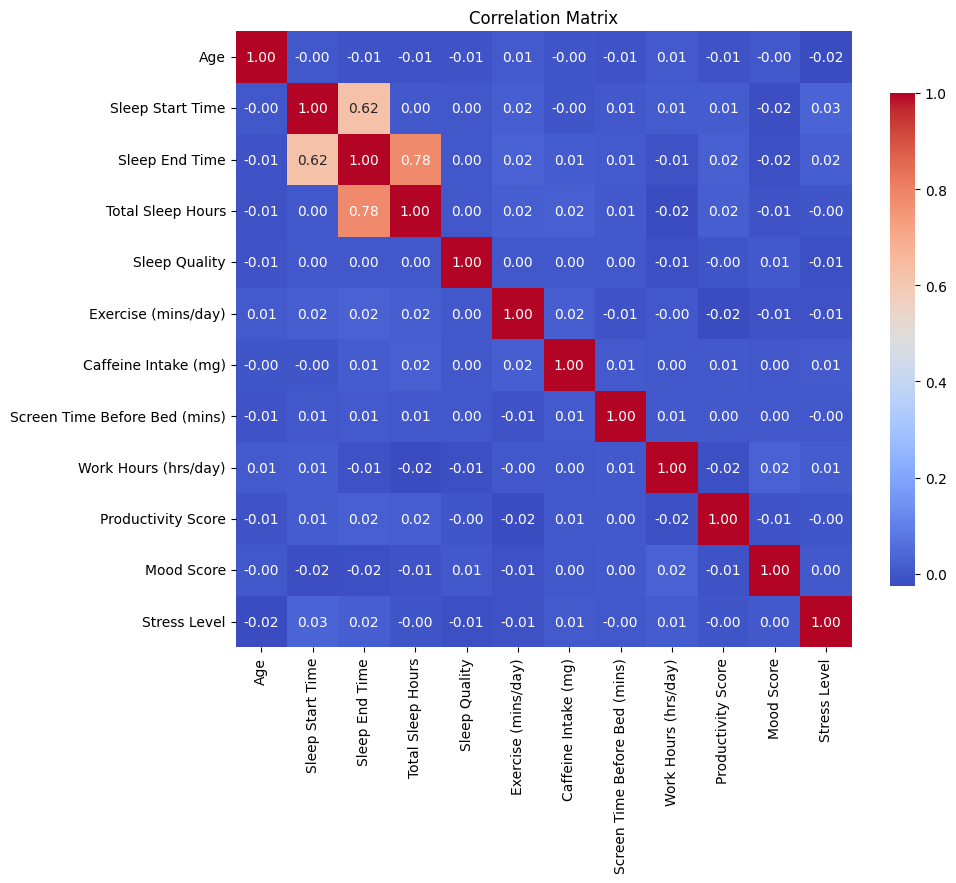

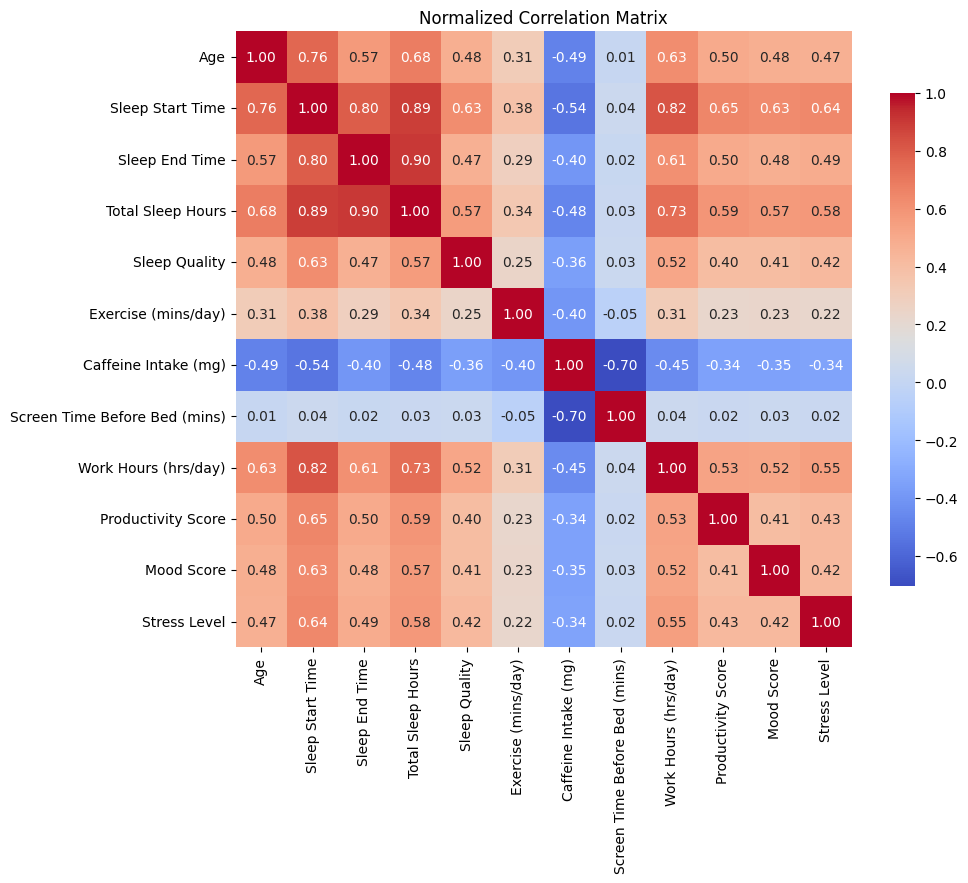

In [34]:
# plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sleepcycle_dataframe.select_dtypes(exclude='object').corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()

# plot normalized correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sleepcycle_dataframe_normalized.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Normalized Correlation Matrix')
plt.show()

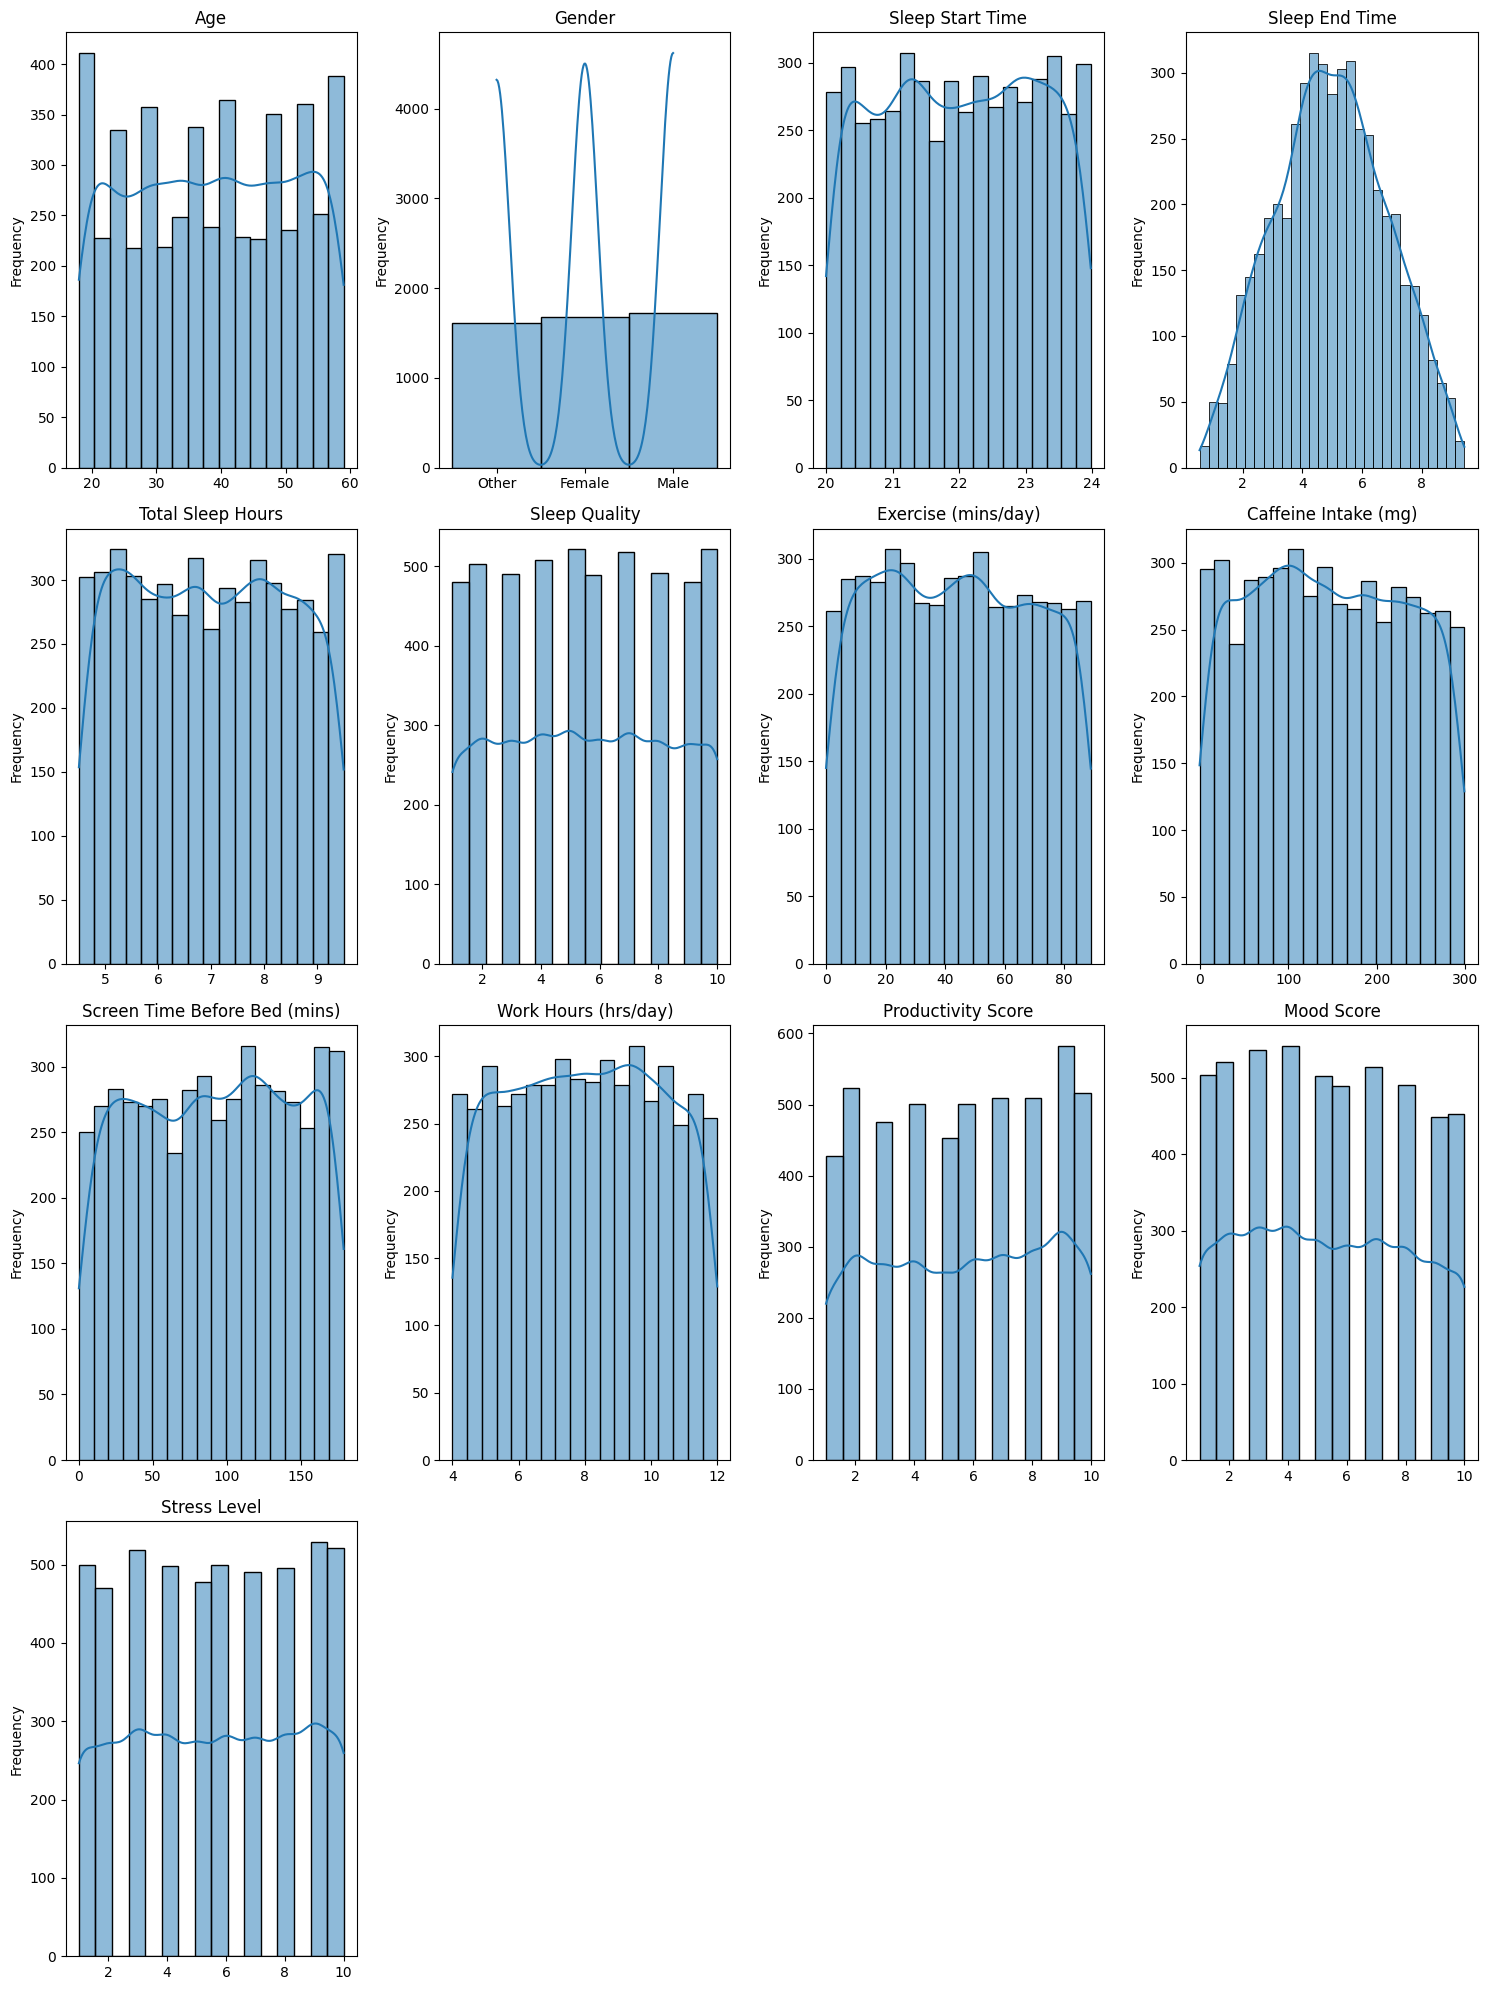

In [35]:
import math

# plot distribution of each feature
num_features = len(sleepcycle_dataframe.columns)
num_rows = math.ceil(num_features / 4)  # Adjust rows dynamically
plt.figure(figsize=(15, 5 * num_rows))
for i, col in enumerate(sleepcycle_dataframe.columns):
    plt.subplot(num_rows, 4, i + 1)
    sns.histplot(sleepcycle_dataframe[col], kde=True)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

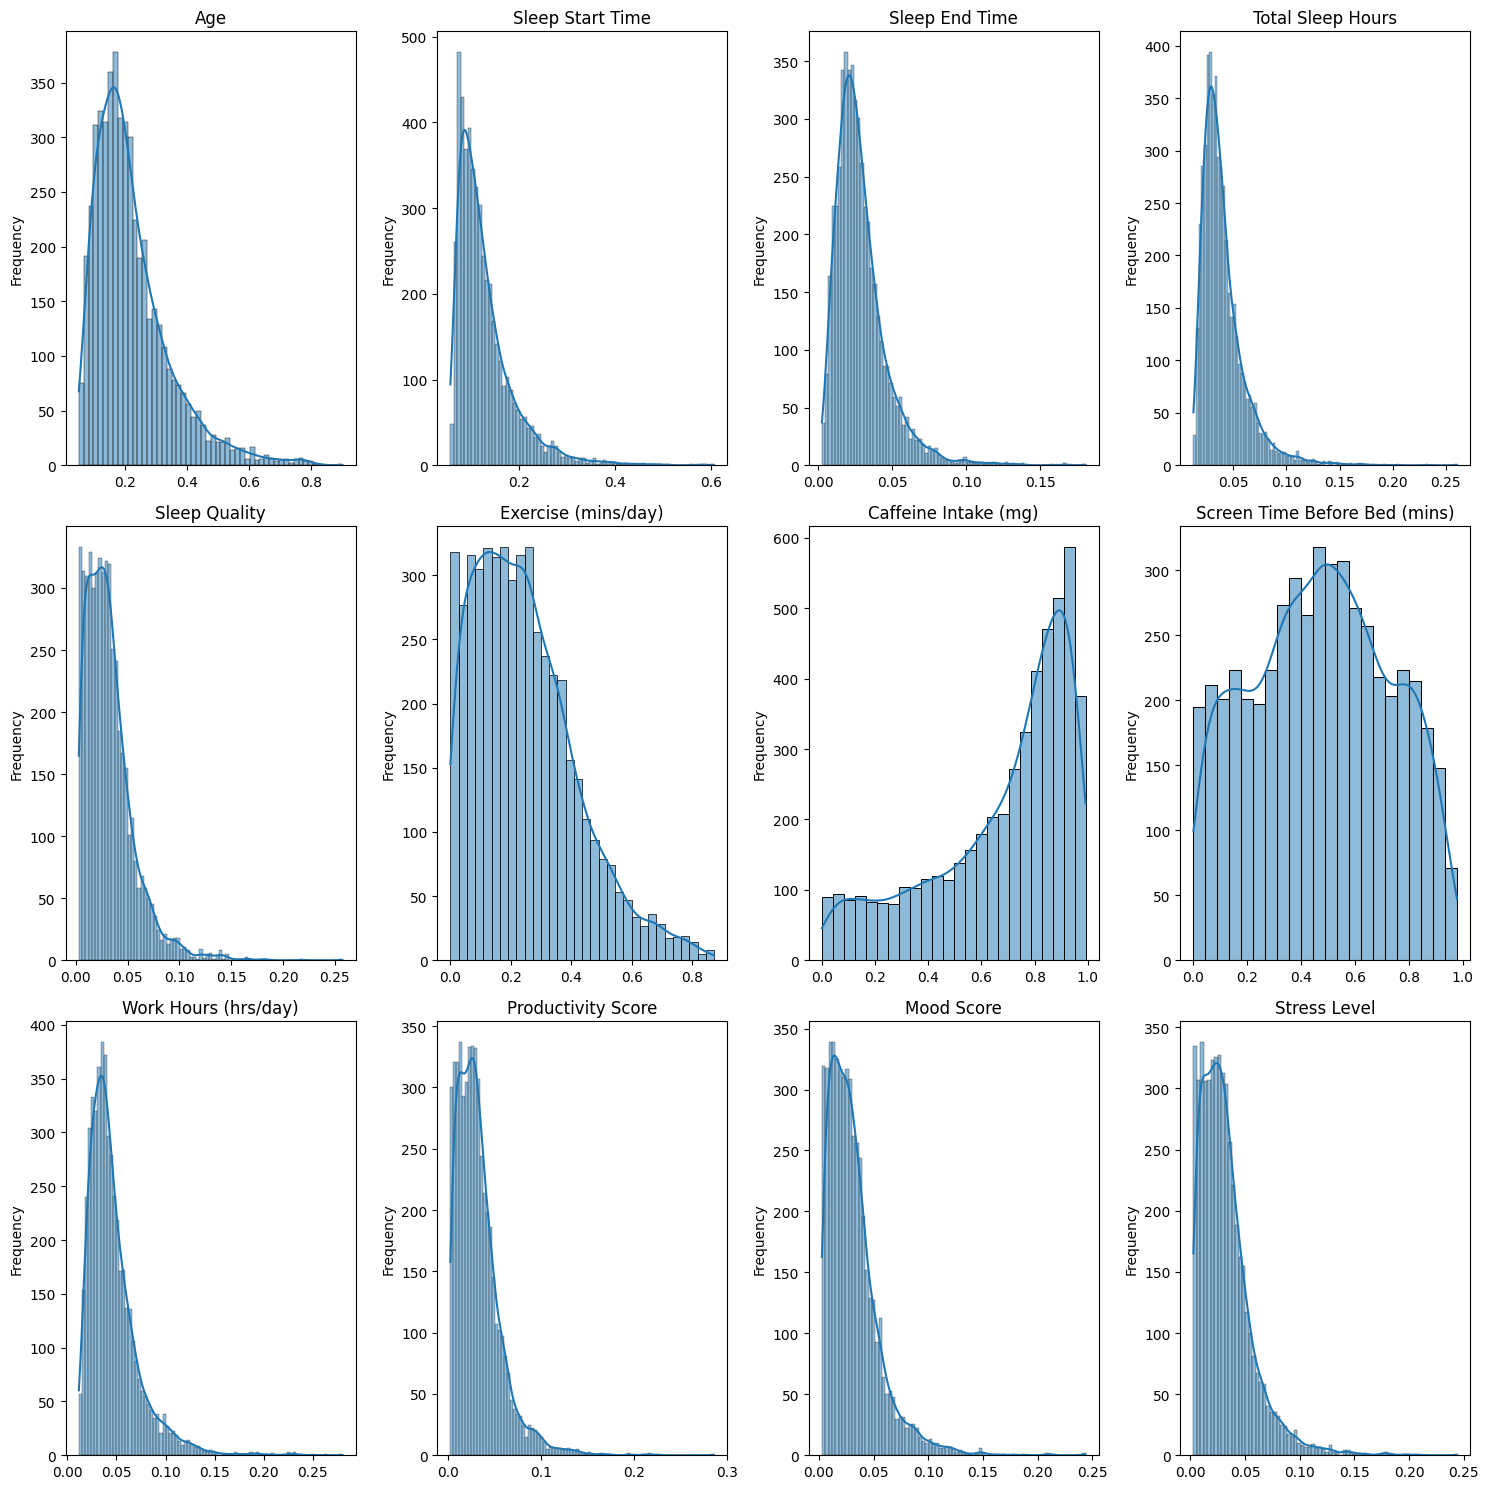

In [36]:
# plot distribution of each feature in normalized dataframe
num_features_normalized = len(sleepcycle_dataframe_normalized.columns)
num_rows_normalized = math.ceil(num_features_normalized / 4)  # Adjust rows dynamically
plt.figure(figsize=(15, 5 * num_rows_normalized))
for i, col in enumerate(sleepcycle_dataframe_normalized.columns):
    plt.subplot(num_rows_normalized, 4, i + 1)
    sns.histplot(sleepcycle_dataframe_normalized[col], kde=True)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

I can see that the ranges between different features vary greatly (e.g. self-reported scores being 1-10 while other features like caffeine intake going from 0-300mg). This suggests the need to scale numerical features. In addition, Gender will need encoding to be useful (onehot encoding works since gender is nominal).

### Preparing the Dataset for Training

For this dataset in general, I will be using pipelines and grid search to more effectively determine the highest performing scaler and hyperparameter(s).

In [37]:
# Split dataset into feature and target dataframes
X = sleepcycle_dataframe.drop(['Sleep Quality', 'Date', 'Person_ID'], axis=1)   # drop ID and Date; likely not informative to sleep quality
y = sleepcycle_dataframe['Sleep Quality']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Identify categorical/numerical types for pipeline processing
categorical_columns = ['Gender']
#numerical_columns = ['Age', 'Sleep Start Time', 'Sleep End Time', 'Total Sleep Hours', 'Exercise (mins/day)', 'Caffeine Intake (mg)',
#                     'Screen Time Before Bed (mins)', 'Work Hours (hrs/day)', 'Productivity Score', 'Mood Score', 'Stress Level']
numerical_columns = ['Total Sleep Hours', 'Sleep Start Time','Productivity Score', 'Exercise (mins/day)', 'Caffeine Intake (mg)', 'Screen Time Before Bed (mins)', 
                     'Work Hours (hrs/day)', 'Stress Level']

# ColumnTransformer for pipelined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(), categorical_columns)
    ])

# Build pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# parameter grid searching for best scaling method
param_grid = {
    'preprocessor__num': [StandardScaler(), RobustScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]
}

# scale test set
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

KeyError: "['Date', 'Person_ID'] not found in axis"

In [ ]:
grid = GridSearchCV(pipeline, param_grid, cv=5, return_train_score=True)

grid.fit(X_train, y_train)

print(f"Best scaler: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_}")
print(f"Test score: {grid.score(X_test, y_test)}")

# Predictions
y_pred = grid.predict(X_test)

# Metrics
print(f"\nRMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")


Best scaler: {'preprocessor__num': StandardScaler()}
Best cross-validation score: -0.006573589843729133
Test score: -0.0031542857661501777

RMSE: 2.892842504945825
R2: -0.0031542857661501777
MAE: 2.519762464991713
